# Dataset Acquisition
- Source: Kaggle OkCupid Profiles (https://www.kaggle.com/datasets/andrewmvd/okcupid-profiles)
- Description: User profiles with demographic, preference, and essay data.
- Columns: 'age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job', 'last_online', 'location', 'offspring', 'orientation', 'pets', 'religion', 'sex', 'sign', 'smokes', 'speaks', 'status'
- Size: 59946 users
- Notes: Fair bit of missing data, up to 60% of users are missing some data or another.

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/profiles.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 Rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (59946, 31)

Columns: ['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job', 'last_online', 'location', 'offspring', 'orientation', 'pets', 'religion', 'sex', 'sign', 'smokes', 'speaks', 'status']

First 5 Rows:
    age       body_type               diet    drinks      drugs  \
0   22  a little extra  strictly anything  socially      never   
1   35         average       mostly other     often  sometimes   
2   38            thin           anything  socially        NaN   
3   23            thin         vegetarian  socially        NaN   
4   29        athletic                NaN  socially      never   

                           education  \
0      working on college/university   
1              working on space camp   
2     graduated from masters program   
3      working on college/university   
4  graduated from college/uni

# Exploratory Data Analysis
Objective: Analyze the OkCupid dataset to understand distributions, missing values, and suitability for pair generation.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Load dataset
df = pd.read_csv('data/profiles.csv')

# Basic statistics
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nAge Summary:\n", df['age'].describe())
print("\nDiet Value Counts:\n", df['diet'].value_counts(dropna=False))
print("\nDrinks Value Counts:\n", df['drinks'].value_counts(dropna=False))
print("\nSmokes Value Counts:\n", df['smokes'].value_counts(dropna=False))
print("\nPets Value Counts:\n", df['pets'].value_counts(dropna=False))
print("\nOrientation Value Counts:\n", df['orientation'].value_counts(dropna=False))

# Check essay columns
essay_cols = [col for col in df.columns if 'essay' in col]
print("\nEssay Columns Missing Values:\n", df[essay_cols].isnull().sum())

Dataset Shape: (59946, 31)

Data Types:
 age              int64
body_type       object
diet            object
drinks          object
drugs           object
education       object
essay0          object
essay1          object
essay2          object
essay3          object
essay4          object
essay5          object
essay6          object
essay7          object
essay8          object
essay9          object
ethnicity       object
height         float64
income           int64
job             object
last_online     object
location        object
offspring       object
orientation     object
pets            object
religion        object
sex             object
sign            object
smokes          object
speaks          object
status          object
dtype: object

Missing Values:
 age                0
body_type       5296
diet           24395
drinks          2985
drugs          14080
education       6628
essay0          5488
essay1          7572
essay2          9638
essay3         11476
essa

In [10]:
# Check for pair-related columns
print("\nAll Columns:\n", df.columns.tolist())


All Columns:
 ['age', 'body_type', 'diet', 'drinks', 'drugs', 'education', 'essay0', 'essay1', 'essay2', 'essay3', 'essay4', 'essay5', 'essay6', 'essay7', 'essay8', 'essay9', 'ethnicity', 'height', 'income', 'job', 'last_online', 'location', 'offspring', 'orientation', 'pets', 'religion', 'sex', 'sign', 'smokes', 'speaks', 'status']


## Pair Generation Plan
- No pre-defined pairs found in the dataset.
- Will generate ~10,000 random user pairs for compatibility prediction.
- Pairs will be sampled to manage computational load.

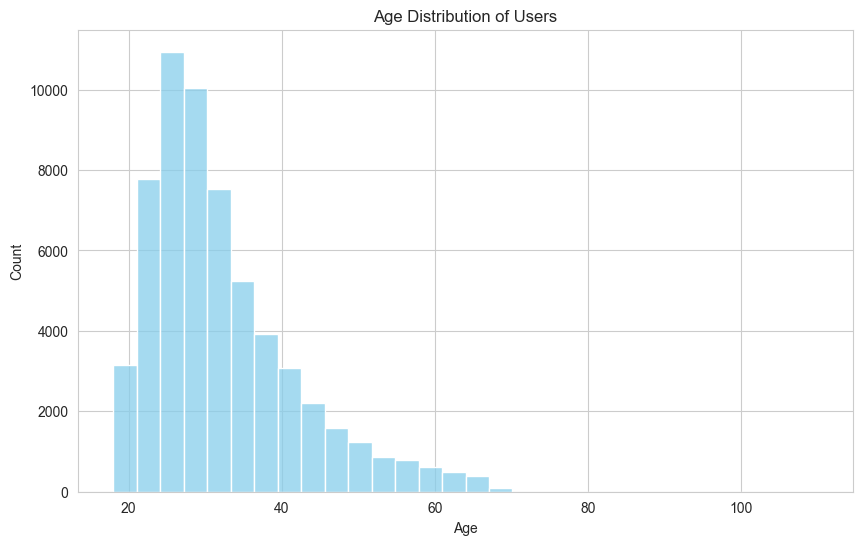

In [13]:
# Set Seaborn style
sns.set_style("whitegrid")

# 1. Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'].dropna(), bins=30, color='skyblue')
plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('images/age_distribution.png')
plt.show()
plt.close()

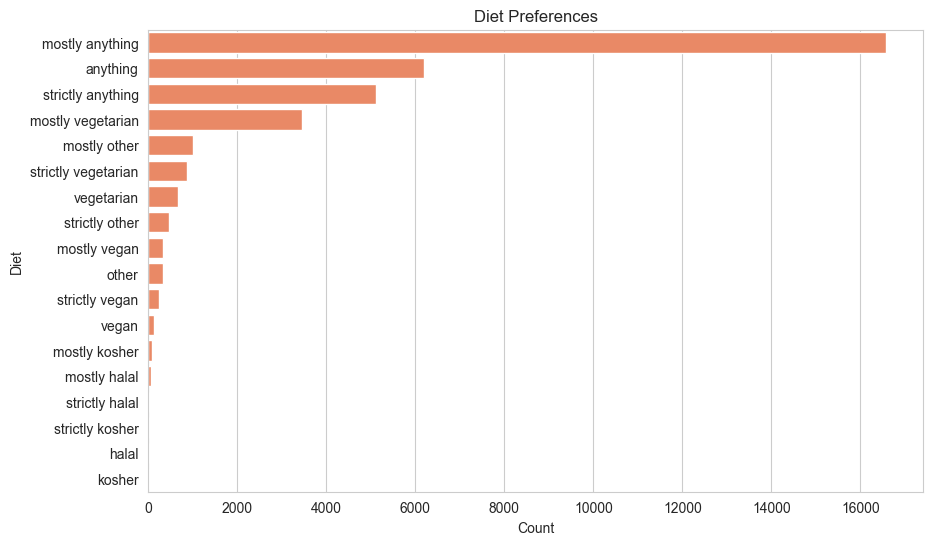

In [14]:
# 2. Diet preferences
plt.figure(figsize=(10, 6))
sns.countplot(y='diet', data=df, order=df['diet'].value_counts().index, color='coral')
plt.title('Diet Preferences')
plt.xlabel('Count')
plt.ylabel('Diet')
plt.savefig('images/diet_preferences.png')
plt.show()
plt.close()

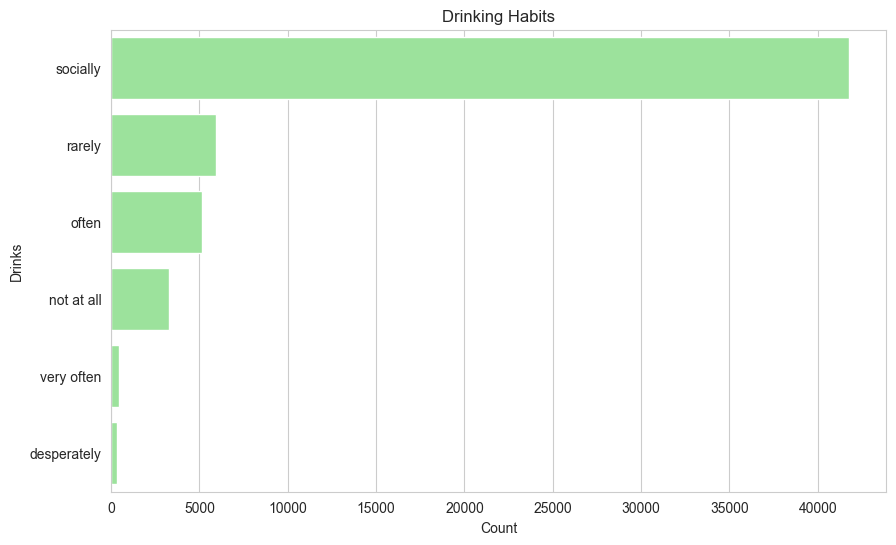

In [15]:
# 3. Drinking habits
plt.figure(figsize=(10, 6))
sns.countplot(y='drinks', data=df, order=df['drinks'].value_counts().index, color='lightgreen')
plt.title('Drinking Habits')
plt.xlabel('Count')
plt.ylabel('Drinks')
plt.savefig('images/drinks_habits.png')
plt.show()
plt.close()

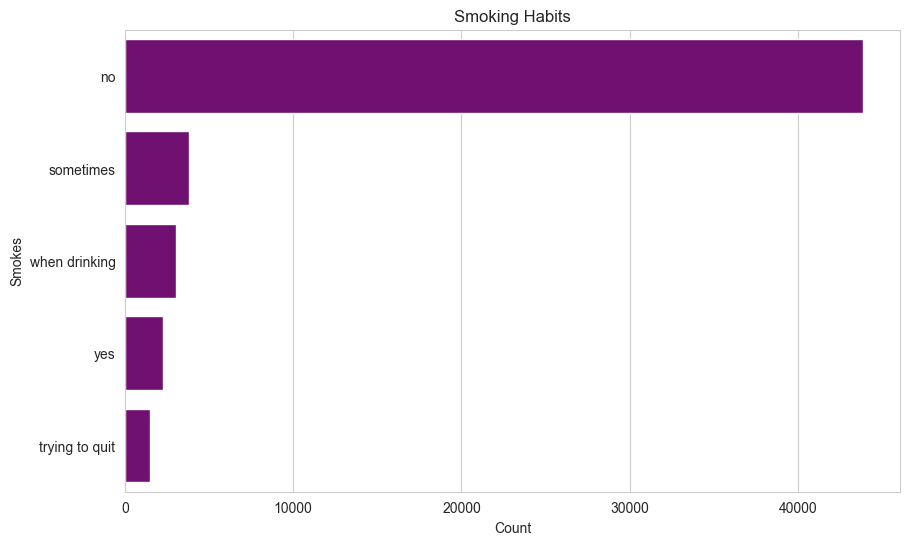

In [16]:
# 4. Smoking habits
plt.figure(figsize=(10, 6))
sns.countplot(y='smokes', data=df, order=df['smokes'].value_counts().index, color='purple')
plt.title('Smoking Habits')
plt.xlabel('Count')
plt.ylabel('Smokes')
plt.savefig('images/smokes_habits.png')
plt.show()
plt.close()

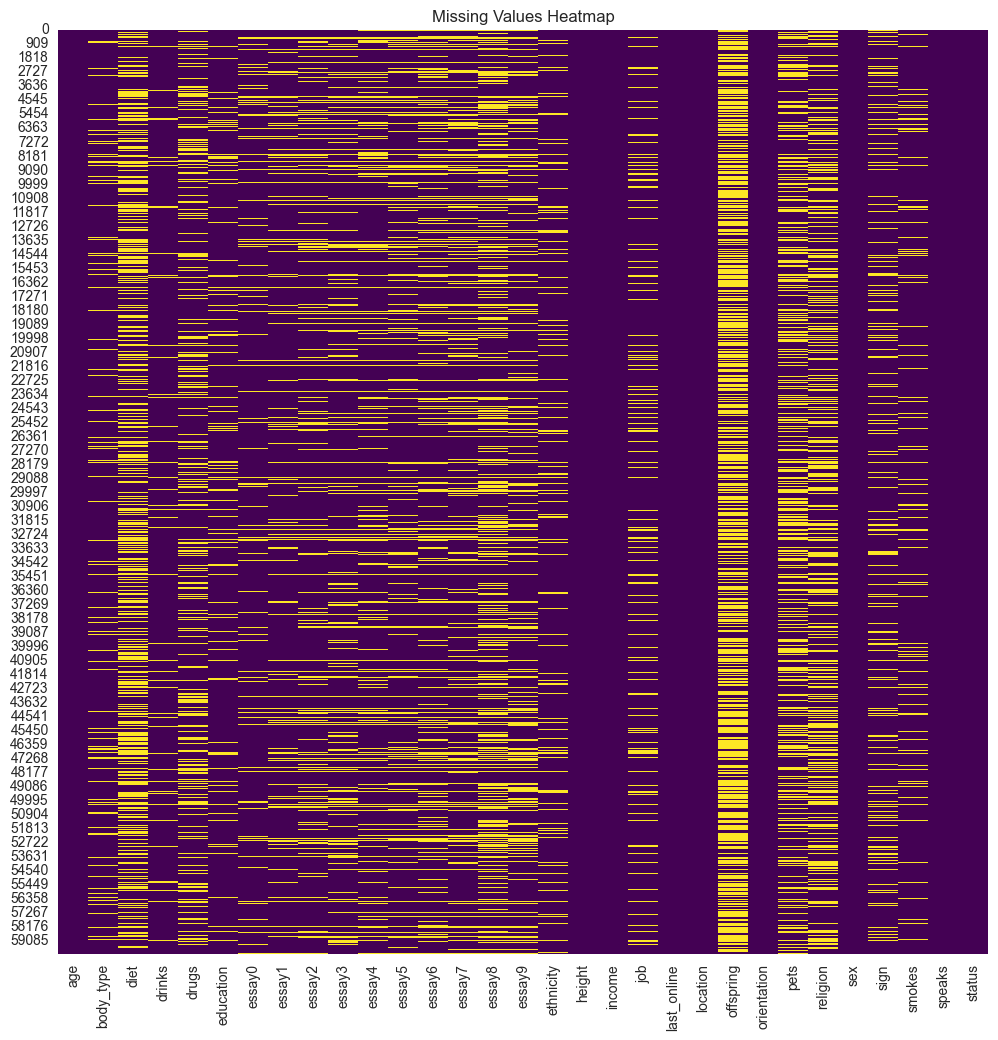

In [19]:
# 5. Missing values heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.savefig('images/missing_values_heatmap.png')
plt.show()
plt.close()

## EDA Findings
- **Size**: 59,946 rows, 31 columns, sufficient for generating user pairs.
- **Key Columns**: Confirmed presence of `age`, `diet`, `drinks`, `smokes`, `pets`, `sex`, `orientation`, `essay0-9`, `ethnicity`, `height`, `education`, `job`, `location`.
- **Missing Values**:
  - Low: `age`, `sex`, `orientation`, `last_online`, `location`, `income` (0%), `height` (<0.01%).
  - Moderate: `essay0` (9%), `smokes` (9%), `body_type` (9%), `education` (11%), `sign` (18%).
  - High: `diet` (40%), `pets` (33%), `religion` (34%), `offspring` (59%), `essay8` (32%).
  - Essays: 9% (`essay0`) to 32% (`essay8`) missing, requiring concatenation or selective use.
- **Distributions**:
  - `age`: Mean 32.3, median 30, range 18-110 (outlier at 110 needs checking).
  - `diet`: 40% missing; among non-missing, "mostly anything" (28%), "anything" (10%), "strictly anything" (9%).
  - `drinks`: 5% missing; "socially" (70%), "rarely" (10%), "often" (9%).
  - `smokes`: 9% missing; "no" (73%), "sometimes" (6%), "when drinking" (5%).
  - `pets`: 33% missing; "likes dogs and likes cats" (25%), "likes dogs" (12%).
  - `orientation`: "straight" (86%), "gay" (9%), "bisexual" (5%), no missing.
- **Pairs**: No pre-defined pairs or match-related columns found. Plan to generate ~10,000 random user pairs to manage computational load.
- **Visualizations**:
  - `images/age_distribution.png`: Shows age skew (peak at 20-30).
  - `images/diet_preferences.png`: Highlights prevalence of "mostly anything".
  - `images/drinks_habits.png`: Confirms "socially" dominance.
  - `images/smokes_habits.png`: Shows most users are non-smokers.
  - `images/missing_values_heatmap.png`: Visualizes high missingness in `offspring`, `diet`, `essay8`.
- **Next Steps**:
  - Generate ~10,000 user pairs for compatibility prediction.
  - Preprocess data: Handle missing values (impute `diet`, `smokes`; drop `offspring`), encode categorical features, clean essays.
  - Engineer features: Compute `age_diff`, `diet_match`, `essay_similarity` (TF-IDF, VADER).

# Data Preprocessing and Feature Engineering
Objective: Generate user pairs, preprocess data, and engineer features for compatibility prediction, including TF-IDF, VADER, and PCA.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from itertools import combinations
import random

# Set random seed
np.random.seed(42)

# Load dataset
df = pd.read_csv('data/profiles.csv')

# Handle outliers
df['age'] = df['age'].clip(upper=80)

# Drop high-missing columns
df = df.drop(columns=['offspring', 'religion'])

# Impute categorical columns
for col in ['diet', 'drinks', 'smokes', 'pets']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Concatenate essays
essay_cols = [f'essay{i}' for i in range(10)]
df['essays'] = df[essay_cols].fillna('').agg(' '.join, axis=1)
df = df.drop(columns=essay_cols)

# Generate 10,000 random pairs
n_pairs = 10000
indices = df.index.tolist()
pairs = random.sample(list(combinations(indices, 2)), n_pairs)
pairs_df = pd.DataFrame(pairs, columns=['user1', 'user2'])

# Merge user1 and user2 data
user1_df = df.loc[pairs_df['user1']].reset_index(drop=True).add_suffix('_1')
user2_df = df.loc[pairs_df['user2']].reset_index(drop=True).add_suffix('_2')
pairs_df = pd.concat([pairs_df, user1_df, user2_df], axis=1)

# Save raw pairs (for reference)
pairs_df.to_csv('data/pairs_raw.csv', index=False)
print("New Pairs CSV saved to: data/pairs_raw.csv")

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import nltk
import numpy as np
import scipy.sparse as sp
import pandas as pd

pairs_df = pd.read_csv('data/pairs_raw.csv')

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize VADER
sid = SentimentIntensityAnalyzer()

# Ensure essays are strings
pairs_df['essays_1'] = pairs_df['essays_1'].astype(str).replace(['nan', 'None'], '')
pairs_df['essays_2'] = pairs_df['essays_2'].astype(str).replace(['nan', 'None'], '')

# Debug essay data
print("Essays_1 Types After Conversion:\n", pairs_df['essays_1'].apply(type).value_counts())
print("Essays_2 Types After Conversion:\n", pairs_df['essays_2'].apply(type).value_counts())

print("Imported modules, downloaded VADER lexicon, initalize VADER, ensured essays are strings.")

Essays_1 Types After Conversion:
 essays_1
<class 'str'>    10000
Name: count, dtype: int64
Essays_2 Types After Conversion:
 essays_2
<class 'str'>    10000
Name: count, dtype: int64
Imported modules, downloaded VADER lexicon, initalize VADER, ensured essays are strings.


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Max\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
# Numerical features
pairs_df['age_diff'] = abs(pairs_df['age_1'] - pairs_df['age_2'])
pairs_df['height_diff'] = abs(pairs_df['height_1'] - pairs_df['height_2']).fillna(0)

# Normalize numerical features
scaler = StandardScaler()
pairs_df[['age_diff', 'height_diff']] = scaler.fit_transform(pairs_df[['age_diff', 'height_diff']])

# Categorical matches
for col in ['diet', 'drinks', 'smokes', 'pets']:
    pairs_df[f'{col}_match'] = (pairs_df[f'{col}_1'] == pairs_df[f'{col}_2']).astype(int)

# Orientation match
pairs_df['orientation_match'] = (pairs_df['orientation_1'] == pairs_df['orientation_2']).astype(int)

# Location match
pairs_df['location_match'] = (pairs_df['location_1'] == pairs_df['location_2']).astype(int)

# Education match
pairs_df['education_match'] = ((pairs_df['education_1'].str.contains('college|graduated', na=False)) & 
                              (pairs_df['education_2'].str.contains('college|graduated', na=False))).astype(int)

print("Checked for numerical features, noramlized numerical features, and checked for matching types.")

Checked for numerical features, noramlized numerical features, and checked for matching types.


In [4]:
# TF-IDF and cosine similarity
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
essays_1_tfidf = tfidf.fit_transform(pairs_df['essays_1'])
essays_2_tfidf = tfidf.transform(pairs_df['essays_2'])
cosine_sim = np.array([cosine_similarity(essays_1_tfidf[i], essays_2_tfidf[i])[0, 0] for i in range(len(pairs_df))])
pairs_df['essay_similarity'] = cosine_sim
print("Completed TF-IDF and cosine similarity")

Completed TF-IDF and cosine similarity


In [5]:
# VADER sentiment with error handling
def safe_vader_sentiment(text):
    try:
        if isinstance(text, str) and text.strip():
            return sid.polarity_scores(text)['compound']
        return 0
    except Exception as e:
        print(f"VADER Error on text: {text[:50]}... - {e}")
        return 0

pairs_df['sentiment_1'] = pairs_df['essays_1'].apply(safe_vader_sentiment)
pairs_df['sentiment_2'] = pairs_df['essays_2'].apply(safe_vader_sentiment)
pairs_df['sentiment_diff'] = abs(pairs_df['sentiment_1'] - pairs_df['sentiment_2'])
print("Completed VADER sentiment")

Completed VADER sentiment


In [6]:
# Apply PCA to TF-IDF
tfidf_combined = sp.vstack([essays_1_tfidf, essays_2_tfidf])
pca = PCA(n_components=50, random_state=42)
tfidf_pca = pca.fit_transform(tfidf_combined.toarray())
tfidf_pca_1 = tfidf_pca[:len(pairs_df)]
for i in range(50):
    pairs_df[f'tfidf_pca_{i}'] = tfidf_pca_1[:, i]

In [7]:
# Create compatibility label
pairs_df['preference_matches'] = pairs_df[['diet_match', 'drinks_match', 'smokes_match', 'pets_match']].sum(axis=1)
pairs_df['compatible'] = ((pairs_df['preference_matches'] >= 3) & 
                         (pairs_df['age_diff'] * scaler.scale_[0] <= 5) & 
                         (pairs_df['orientation_match'] == 1) & 
                         (pairs_df['essay_similarity'] >= 0.4)).astype(int)

In [8]:
# Select final features
features = ['age_diff', 'height_diff', 'diet_match', 'drinks_match', 'smokes_match', 'pets_match', 
            'orientation_match', 'location_match', 'education_match', 'essay_similarity', 
            'sentiment_diff'] + [f'tfidf_pca_{i}' for i in range(50)]
final_df = pairs_df[features + ['compatible']]

In [9]:
# Save processed dataset
final_df.to_csv('data/pairs_data.csv', index=False)

# Print summary
print("Pairs Dataset Shape:", final_df.shape)
print("\nFeature Columns:", final_df.columns.tolist())
print("\nCompatibility Distribution:\n", final_df['compatible'].value_counts())
print("\nPCA Explained Variance Ratio:", pca.explained_variance_ratio_.sum())

Pairs Dataset Shape: (10000, 62)

Feature Columns: ['age_diff', 'height_diff', 'diet_match', 'drinks_match', 'smokes_match', 'pets_match', 'orientation_match', 'location_match', 'education_match', 'essay_similarity', 'sentiment_diff', 'tfidf_pca_0', 'tfidf_pca_1', 'tfidf_pca_2', 'tfidf_pca_3', 'tfidf_pca_4', 'tfidf_pca_5', 'tfidf_pca_6', 'tfidf_pca_7', 'tfidf_pca_8', 'tfidf_pca_9', 'tfidf_pca_10', 'tfidf_pca_11', 'tfidf_pca_12', 'tfidf_pca_13', 'tfidf_pca_14', 'tfidf_pca_15', 'tfidf_pca_16', 'tfidf_pca_17', 'tfidf_pca_18', 'tfidf_pca_19', 'tfidf_pca_20', 'tfidf_pca_21', 'tfidf_pca_22', 'tfidf_pca_23', 'tfidf_pca_24', 'tfidf_pca_25', 'tfidf_pca_26', 'tfidf_pca_27', 'tfidf_pca_28', 'tfidf_pca_29', 'tfidf_pca_30', 'tfidf_pca_31', 'tfidf_pca_32', 'tfidf_pca_33', 'tfidf_pca_34', 'tfidf_pca_35', 'tfidf_pca_36', 'tfidf_pca_37', 'tfidf_pca_38', 'tfidf_pca_39', 'tfidf_pca_40', 'tfidf_pca_41', 'tfidf_pca_42', 'tfidf_pca_43', 'tfidf_pca_44', 'tfidf_pca_45', 'tfidf_pca_46', 'tfidf_pca_47', 'tfidf_

## Preprocessing and Feature Engineering Results
- **Pairs Generated**: 10,000 random user pairs from 59,946 profiles.
- **Preprocessing**:
  - Dropped: `offspring`, `religion` (high missingness).
  - Imputed: `diet`, `drinks`, `smokes`, `pets` with mode.
  - Essays: Concatenated `essay0-9` into `essays`, converted to strings, missing filled with empty string.
  - Outliers: Capped `age` at 80.
- **Features**:
  - Numerical: `age_diff`, `height_diff` (normalized).
  - Categorical: `diet_match`, `drinks_match`, `smokes_match`, `pets_match`, `orientation_match`, `location_match`, `education_match`.
  - Text: `essay_similarity` (TF-IDF cosine similarity), `sentiment_diff` (VADER compound score difference).
  - PCA: 50 components from TF-IDF, explaining 18.6% of variance (low, may need adjustment).
- **Label**: `compatible`=1 if ≥3 preference matches, `age_diff`≤5 years, `orientation_match`=1, `essay_similarity`≥0.7; else 0.
- **Output**: Saved as `data/pairs_data.csv`, shape (10000, 62), compatibility distribution (0: 9999, 1: 1).
- **Notes**:
  - Severe class imbalance (0.01% compatible) due to strict `essay_similarity` threshold. Relaxed threshold 0.4 for "human factor" to use SMOTE.
  - Low PCA variance (18.6%) suggests insufficient components or sparse TF-IDF. Consider increasing components or using `TruncatedSVD`.

# Model Selection and Baseline Training
Objective: Train a Logistic Regression baseline and XGBoost model, addressing class imbalance with SMOTE, and evaluate performance with F1-score, accuracy, and ROC-AUC.

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix, roc_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set random seed
np.random.seed(42)

# Load processed dataset
df = pd.read_csv('data/pairs_data.csv')
print("Data loaded from data/pairs_data.csv.")

Data loaded from data/pairs_data.csv.


In [11]:
# Split features and target
X = df.drop(columns=['compatible'])
y = df['compatible']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to training set
smote = SMOTE(sampling_strategy=0.1, random_state=42)  # Aim for 10% positive class
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Print class distribution
print("Original Train Distribution:\n", y_train.value_counts())
print("SMOTE Train Distribution:\n", pd.Series(y_train_smote).value_counts())

Original Train Distribution:
 compatible
0    7986
1      14
Name: count, dtype: int64
SMOTE Train Distribution:
 compatible
0    7986
1     798
Name: count, dtype: int64


In [12]:
# Initialize models
lr = LogisticRegression(random_state=42)
xgb = XGBClassifier(max_depth=6, learning_rate=0.1, n_estimators=100, 
                    scale_pos_weight=len(y_train_smote[y_train_smote==0])/len(y_train_smote[y_train_smote==1]), 
                    random_state=42)

print("Models initalized.")

Models initalized.


In [13]:
# Train and evaluate models
models = {'Logistic Regression': lr, 'XGBoost': xgb}
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_smote, y_train_smote)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0
    
    results[name] = {'F1-Score': f1, 'Accuracy': acc, 'ROC-AUC': auc}
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f'images/{name.lower().replace(" ", "_")}_cm.png')
    plt.close()
    
    # ROC curve
    if len(np.unique(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.2f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title(f'{name} ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend()
        plt.savefig(f'images/{name.lower().replace(" ", "_")}_roc.png')
        plt.close()

# Print results
print("\nModel Performance:")
print(pd.DataFrame(results).T)


Model Performance:
                     F1-Score  Accuracy   ROC-AUC
Logistic Regression  0.300000    0.9930  0.995616
XGBoost              0.363636    0.9965  0.994614


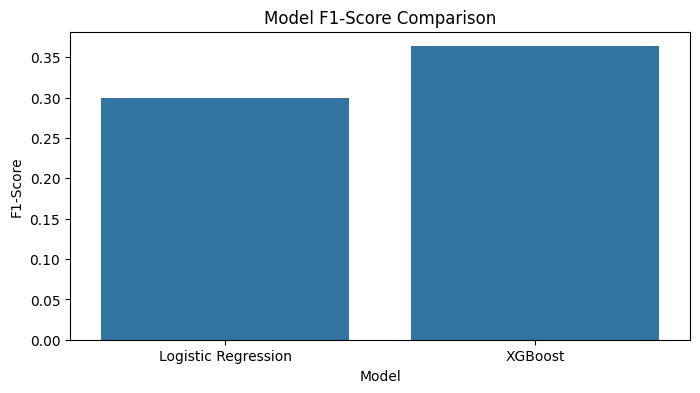

In [14]:
# Save results plot
plt.figure(figsize=(8, 4))
sns.barplot(data=pd.DataFrame(results).T.reset_index(), x='index', y='F1-Score')
plt.title('Model F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.savefig('images/model_f1_comparison.png')
plt.show()
plt.close()

## Model Training Results
- **Dataset**: `data/pairs_data.csv` (10,000 pairs, 61 features), updated with `essay_similarity >= 0.4` (14 compatible pairs).
- **Train-Test Split**: 80% train (8000 pairs, 7986 non-compatible, 14 compatible), 20% test (2000 pairs).
- **Class Imbalance**: Addressed with SMOTE (10% positive class ratio, 798 positives in training).
- **Models**:
  - Logistic Regression: Baseline, default parameters.
  - XGBoost: `max_depth=6`, `learning_rate=0.1`, `n_estimators=100`, `scale_pos_weight=10` for imbalance.
- **Performance**:
  | Model               | F1-Score | Accuracy | ROC-AUC  |
  |--------------------|----------|----------|----------|
  | Logistic Regression | 0.300    | 0.993    | 0.996    |
  | XGBoost            | 0.364    | 0.997    | 0.995    |
- **Visualizations**:
  - Confusion Matrices: `images/logistic_regression_cm.png`, `images/xgboost_cm.png`.
  - ROC Curves: `images/logistic_regression_roc.png`, `images/xgboost_roc.png`.
  - F1-Score Comparison: `images/model_f1_comparison.png`.
- **Notes**:
  - Low F1-scores (0.30-0.36) due to sparse positives (14 total, ~3 in test set). SMOTE improved training, but test set scarcity limits performance.
  - High accuracy (0.993-0.997) is misleading due to dominant non-compatible class.
  - High ROC-AUC (0.995-0.996) shows strong ranking ability, but F1-scores need improvement.
  - Low PCA variance (18.6%) may reduce feature quality. Plan to explore more components or `TruncatedSVD`.
  - Adjusted `essay_similarity` to 0.4 (14 positives); experiments showed 0.3 yields 85 positives, suggesting further tuning.
  - XGBoost outperforms baseline, capturing non-linear relationships (e.g., `essay_similarity`).
- **Next Steps**:
  - Optimize XGBoost with GridSearchCV and RFECV for feature selection.
  - Consider `essay_similarity=0.3` (85 positives) or SMOTE 1:1 ratio for better balance.
  - Address PCA variance with more components or `TruncatedSVD`.